In [1]:
import re 
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from pre_processing_utils import Utils

In [3]:
folder_path = Path.cwd().parent / "data" / "new"

dict_worker_id = {}
for subdir in folder_path.iterdir():
    if subdir.is_dir():
        df = pd.read_csv(subdir / "Request.csv")
        worker_id_list = []
        for key, row in df.iterrows():
            value = row['unique_id']
            if isinstance(value, str):
                value_ = value.split(':')[0]
                if value_ not in worker_id_list:
                    worker_id_list.append(value_)
        dict_worker_id[subdir.name] = {
            idx  + 1: value for idx, value in enumerate(worker_id_list)
        }

#dict_worker_id

In [63]:
folder_path = Path.cwd().parent / "data/new" 

df = pd.DataFrame()
for subdir in folder_path.iterdir():
    if subdir.is_dir():
        if "new" not in subdir.name:
            print(f"Processing {subdir.name}...")
            df1 = pd.read_csv(subdir / "GuessingCoinsGameNode.csv")
            df1["session"] = subdir.name
            
            df = pd.concat([df, df1], ignore_index=True)

df = Utils.parse_dicts_in_dataframe(df)
df['target'] = df['definition'].apply(lambda x: x.get('target_coins', np.nan).get('value', np.nan))
df['guess'] = df['definition'].apply(lambda x: x.get('answer', np.nan))
df['worker_id'] = df['participant_id'].map(dict_worker_id['05-25-batch-1'])
columns = ["session", "network_id", "participant_id", "worker_id", "id", "failed", "failed_reason", "target", "guess"]
df = df[columns]
df.sort_values(by=['session', 'network_id', 'participant_id', 'id'], inplace=True)
df.head(10)

Processing 05-25-batch-1...


,session,network_id,participant_id,worker_id,id,failed,failed_reason,target,guess
0,05-25-batch-1,11,1,61798ab0f4a0bbfe7c050433,11,False,NaN,1,NaN
1,05-25-batch-1,11,1,61798ab0f4a0bbfe7c050433,12,False,NaN,1,2
2,05-25-batch-1,11,1,61798ab0f4a0bbfe7c050433,13,False,NaN,1,4
3,05-25-batch-1,11,1,61798ab0f4a0bbfe7c050433,14,False,NaN,1,2
4,05-25-batch-1,11,1,61798ab0f4a0bbfe7c050433,15,False,NaN,1,1
5,05-25-batch-1,12,4,6a036a8dcb5fdb1ea688ba0a,16,False,NaN,1,NaN
6,05-25-batch-1,12,4,6a036a8dcb5fdb1ea688ba0a,17,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",1,5
7,05-25-batch-1,12,4,6a036a8dcb5fdb1ea688ba0a,18,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",1,6
8,05-25-batch-1,12,4,6a036a8dcb5fdb1ea688ba0a,19,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",1,8
9,05-25-batch-1,12,4,6a036a8dcb5fdb1ea688ba0a,20,True,"fail_on_timeout, UnsuccessfulEndPage, while_lo...",1,10


In [64]:
df['guess'].value_counts()

guess
5     17
4     10
6     10
2      5
1      4
10     3
7      3
3      3
0      3
8      2
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

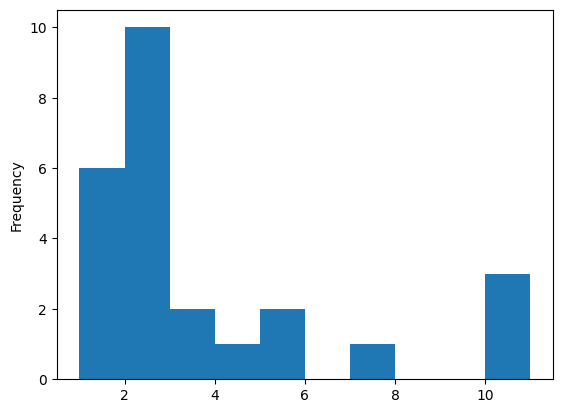

In [48]:
df['participant_id'].value_counts().plot(kind='hist')

In [31]:
df['failed_reason'].value_counts()

failed_reason
fail_on_timeout, UnsuccessfulEndPage, while_loop:Waiting for trial->Participant4->GuessingCoinsGameTrial27                                                                                                                                                                                                                                                                                                                                                                                                                                                 1
fail_on_timeout, UnsuccessfulEndPage, while_loop:Waiting for trial->Participant4->GuessingCoinsGameTrial31                                                                                                                                                                                                                                                                                                                                                   

In [35]:
df[df['failed_reason'].str.contains("sync group below minimum size", na=False)]['worker_id'].unique()

array(['5e8a1827052175000938eb91', '69ee2e8675301578c95e1e60',
       '672c57a8ee24c76a011bf4d7', '6a0df5493e7bdfb3e8ad4caa',
       '65b571deec1559505fc20ac3'], dtype=object)

In [36]:
df[df['failed_reason'].str.contains("GuessingCoinsGameTrial", na=False)]['worker_id'].unique()

array(['6a036a8dcb5fdb1ea688ba0a', '699d0fdf43b9ecfcafe7e52a',
       '5e8a1827052175000938eb91', '671bbaf1bec15d847b871b9b',
       '69808f7c8ff246c7ce92f77c', '69ee2e8675301578c95e1e60',
       '6a048950bab3f5d03e6ef938', '672c57a8ee24c76a011bf4d7',
       '6a0df5493e7bdfb3e8ad4caa', '65b571deec1559505fc20ac3',
       '6993957ffe43ec54a046b703', '67f2e613c09bbf379bd208ea',
       '63ffcb367b500c516d0648a2'], dtype=object)

<Axes: ylabel='Frequency'>

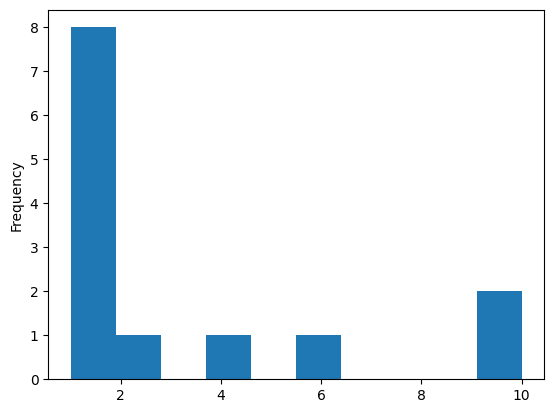

In [49]:
df[df['failed_reason'].str.contains("GuessingCoinsGameTrial", na=False)]['participant_id'].value_counts().plot(kind='hist')